# Customer Churn Prediction — Telecom

> **Goal:** Predict which customers are likely to churn and explain *why*, so the business can act on it.

**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Author:** Santiago Monsalve
**Tools:** pandas · scikit-learn · xgboost · optuna · shap

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Cleaning](#2)
3. [Exploratory Analysis](#3)
4. [Feature Engineering](#4)
5. [Train/Test Split & Preprocessing](#5)
6. [Model Comparison](#6)
7. [Hyperparameter Tuning with Optuna](#7)
8. [Model Evaluation](#8)
9. [Explainability with SHAP](#9)
10. [Business Impact — Profit Curve](#10)
11. [Conclusions](#11)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, precision_recall_curve, f1_score)
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
BLUE, CORAL, GREEN = '#2563EB', '#F97316', '#16A34A'

print('Libraries loaded.')

/Users/santiagomonsalve/Proyecto_DS/Data_Science_Portfolio/Portfolio/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
URL = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(URL)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Loaded: 7,043 rows x 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## 2. Data Cleaning

In [3]:
# TotalCharges sometimes has blank strings instead of NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

print(f'Nulls remaining: {df.isnull().sum().sum()}')
print(f'Churn rate: {df["Churn"].mean():.1%}')

Nulls remaining: 0
Churn rate: 26.5%


## 3. Exploratory Analysis

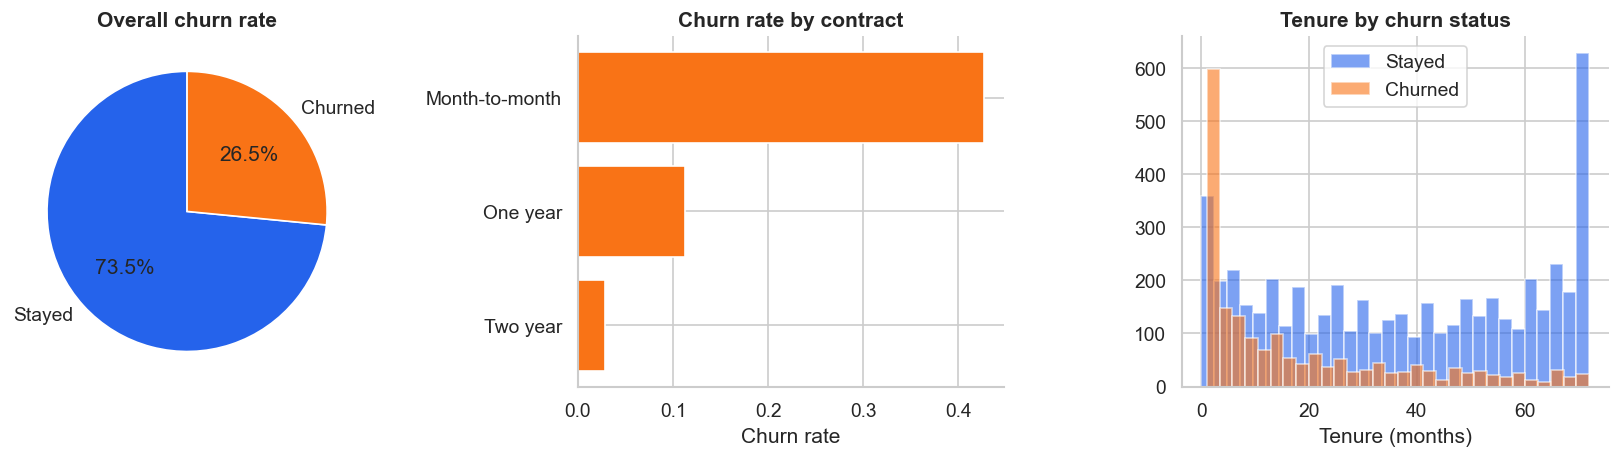

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Churn rate overall
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=[BLUE, CORAL], startangle=90)
axes[0].set_title('Overall churn rate', fontweight='bold')

# Churn by contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values()
axes[1].barh(contract_churn.index, contract_churn.values, color=CORAL)
axes[1].set_title('Churn rate by contract', fontweight='bold')
axes[1].set_xlabel('Churn rate')

# Tenure distribution by churn
for churn_val, color, label in [(0, BLUE, 'Stayed'), (1, CORAL, 'Churned')]:
    axes[2].hist(df[df['Churn']==churn_val]['tenure'], bins=30, alpha=0.6, color=color, label=label)
axes[2].set_title('Tenure by churn status', fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].legend()

plt.tight_layout()
plt.show()

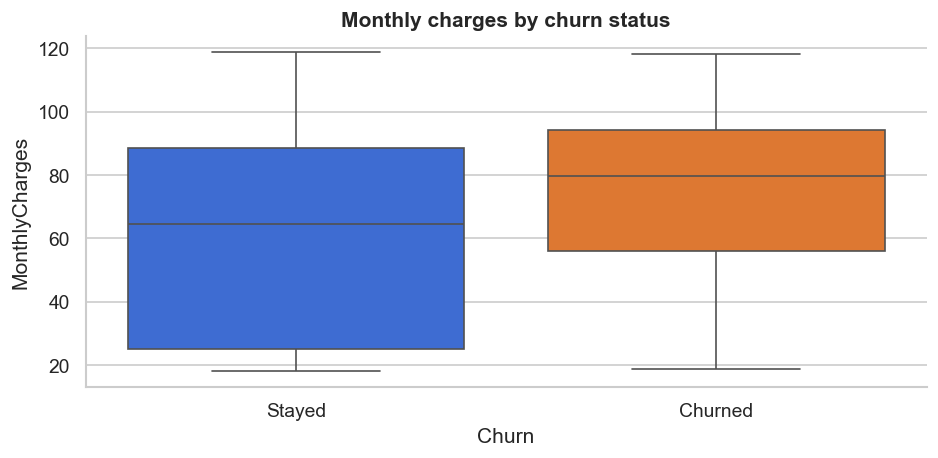

In [5]:
# Monthly charges vs churn
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=[BLUE, CORAL], ax=ax)
ax.set_xticklabels(['Stayed', 'Churned'])
ax.set_title('Monthly charges by churn status', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [6]:
# Tenure buckets — captures non-linear lifecycle effects
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                              labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

# Number of additional services subscribed (engagement signal)
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['n_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# Average monthly spend trend
df['charges_per_tenure'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

# Is the customer on a month-to-month contract with no tech support? (high-risk combo)
df['high_risk_combo'] = (
    (df['Contract'] == 'Month-to-month') & (df['TechSupport'] == 'No')
).astype(int)

print('New features created: tenure_group, n_services, charges_per_tenure, high_risk_combo')
df[['tenure_group', 'n_services', 'charges_per_tenure', 'high_risk_combo']].head()

New features created: tenure_group, n_services, charges_per_tenure, high_risk_combo


,tenure_group,n_services,charges_per_tenure,high_risk_combo
0,0-1yr,1,29.850000,1
1,2-4yr,2,55.573529,0
2,0-1yr,2,54.075000,1
3,2-4yr,3,40.905556,0
4,0-1yr,0,75.825000,1


## 5. Train/Test Split & Preprocessing

In [7]:
# Encode categoricals
df_model = df.copy()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
if 'tenure_group' in df_model.columns:
    cat_cols.append('tenure_group')
    df_model['tenure_group'] = df_model['tenure_group'].astype(str)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} · Test: {X_test.shape[0]:,}')
print(f'Train churn rate: {y_train.mean():.1%} · Test churn rate: {y_test.mean():.1%}')

Train: 5,634 · Test: 1,409
Train churn rate: 26.5% · Test churn rate: 26.5%


## 6. Model Comparison

In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
}

results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'XGBoost': xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
    }

    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
        model.fit(X_train, y_train)
        test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        results.append({
            'Model': name,
            'CV AUC (mean)': scores.mean(),
            'CV AUC (std)': scores.std(),
            'Test AUC': test_auc
        })

    results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False)
    results_df
    model.fit(X_train, y_train)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results.append({
        'Model': name,
        'CV AUC (mean)': scores.mean(),
        'CV AUC (std)': scores.std(),
        'Test AUC': test_auc
    })

results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False)
results_df

,Model,CV AUC (mean),CV AUC (std),Test AUC
0,Logistic Regression,0.843975,0.011761,0.839965
3,LightGBM,0.835625,0.010095,0.835604
4,LightGBM,0.835625,0.010095,0.835604
1,Random Forest,0.829237,0.009005,0.821881
2,XGBoost,0.825623,0.008176,0.815551


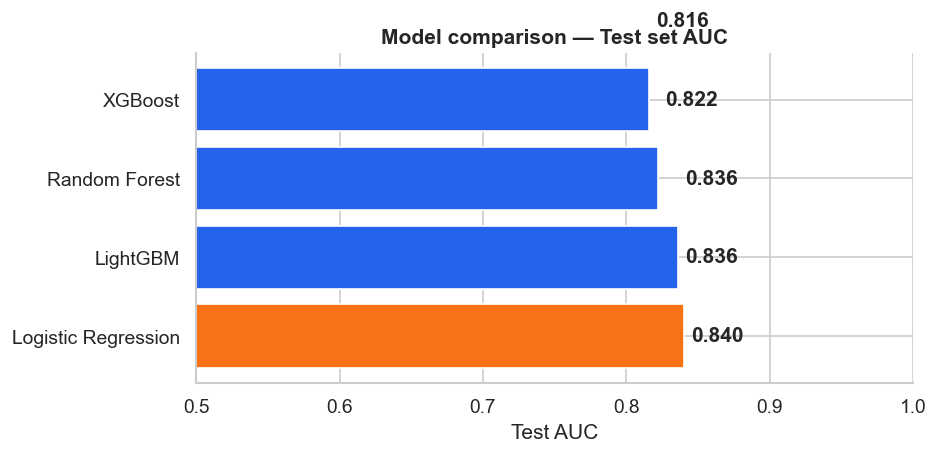

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [CORAL if i == 0 else BLUE for i in range(len(results_df))]
ax.barh(results_df['Model'], results_df['Test AUC'], color=colors)
ax.set_xlabel('Test AUC')
ax.set_xlim(0.5, 1.0)
ax.set_title('Model comparison — Test set AUC', fontweight='bold')
for i, v in enumerate(results_df['Test AUC']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning with Optuna

In [10]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=False)

print(f'Best CV AUC: {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

Best CV AUC: 0.8486
Best params: {'n_estimators': 329, 'max_depth': 5, 'learning_rate': 0.010090912647338432, 'subsample': 0.6055980183997496, 'colsample_bytree': 0.6808516102991248, 'min_child_weight': 9, 'reg_alpha': 0.2381085488829171, 'reg_lambda': 0.02089172213392916}


In [11]:
best_params = study.best_params
best_params.update({'eval_metric': 'logloss', 'random_state': 42})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

test_auc_tuned = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f'Tuned XGBoost — Test AUC: {test_auc_tuned:.4f}')
print(f'Improvement over baseline: +{(test_auc_tuned - results_df.iloc[0]["Test AUC"])*100:.2f} pts')

Tuned XGBoost — Test AUC: 0.8491
Improvement over baseline: +0.91 pts


## 8. Model Evaluation

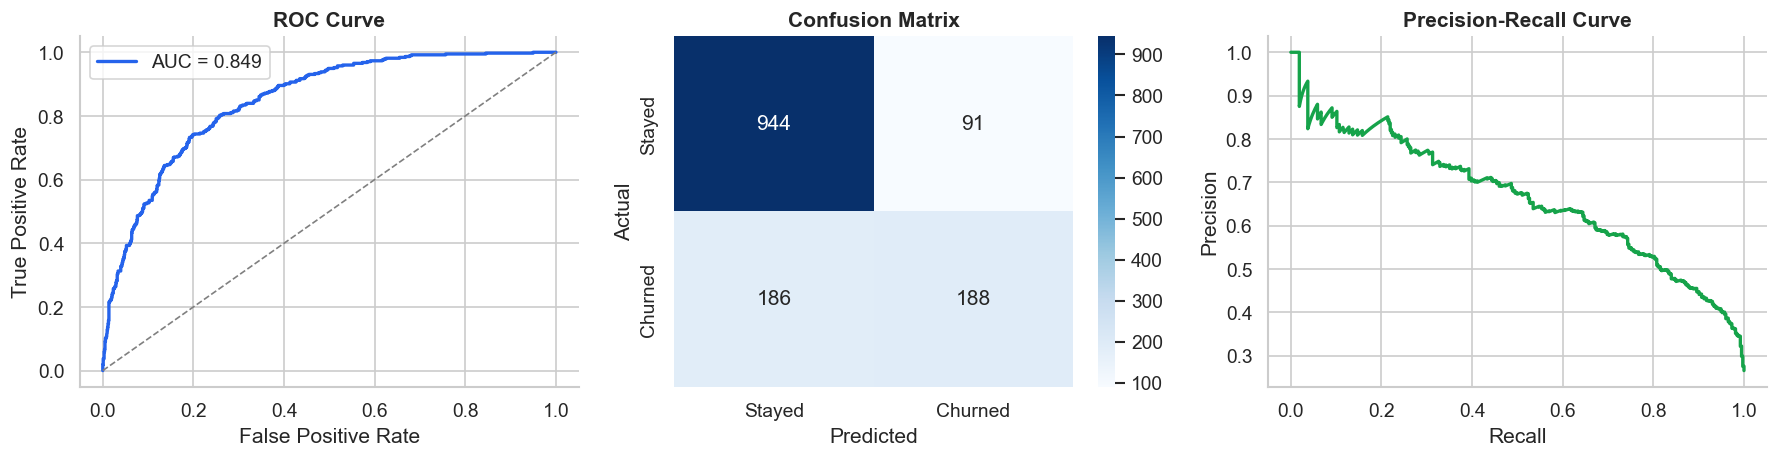

              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.67      0.50      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [12]:
y_pred_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color=BLUE, lw=2, label=f'AUC = {test_auc_tuned:.3f}')
axes[0].plot([0, 1], [0, 1], color='gray', ls='--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[1].set_title('Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
axes[2].plot(recall, precision, color=GREEN, lw=2)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

## 9. Explainability with SHAP

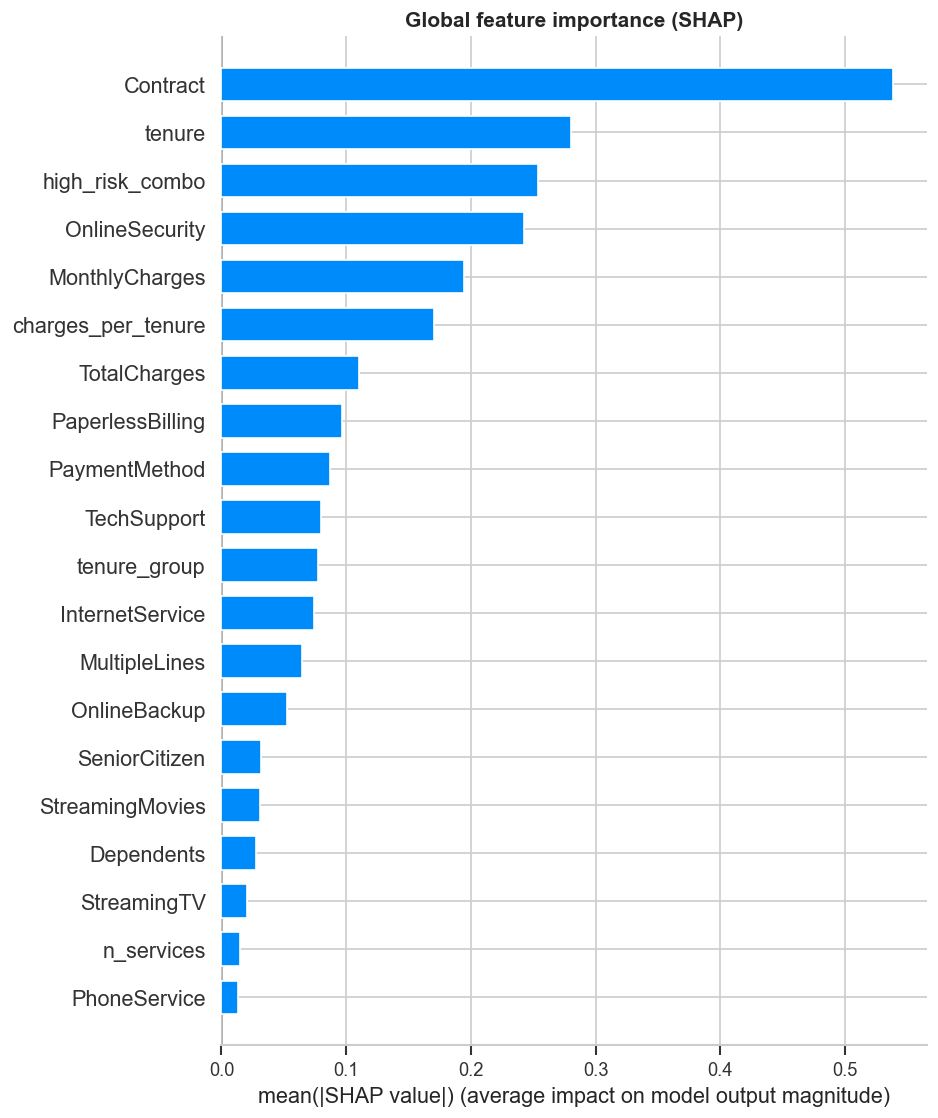

In [13]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Global feature importance
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Global feature importance (SHAP)', fontweight='bold')
plt.tight_layout()
plt.show()

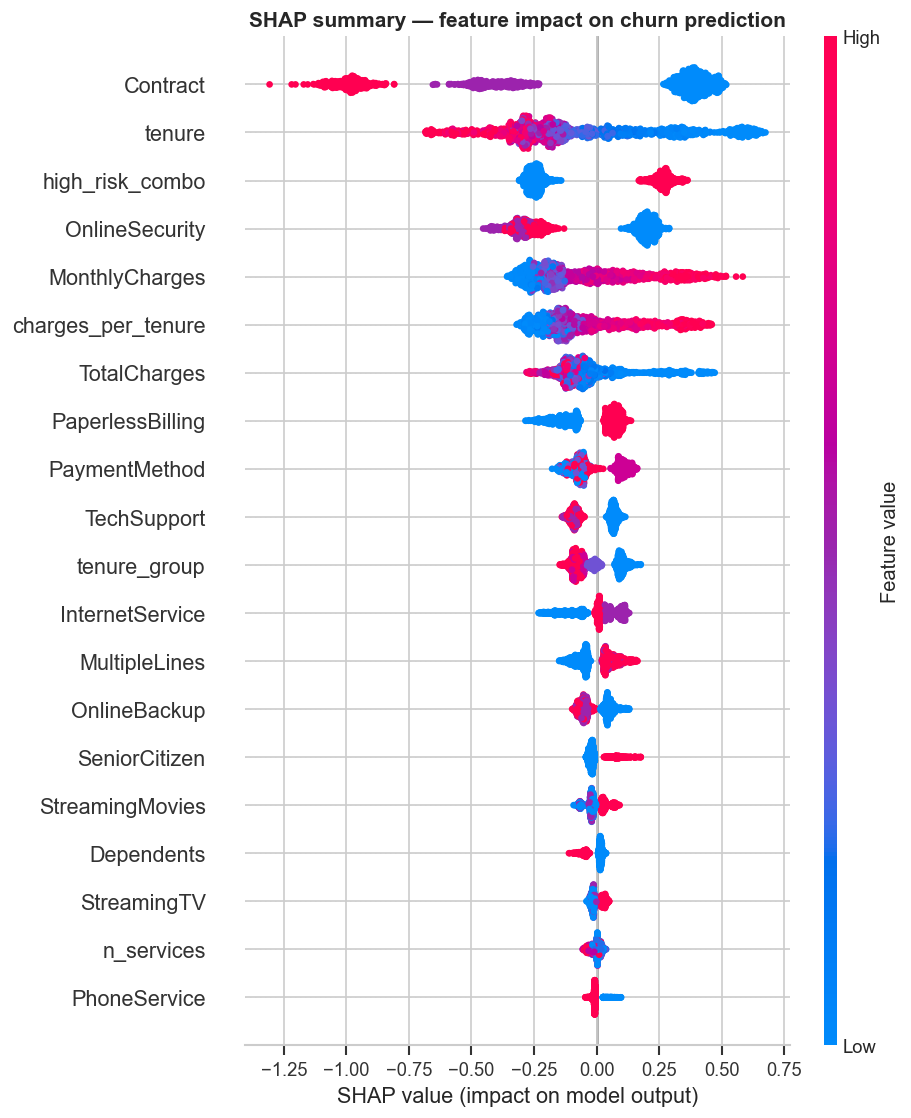

In [14]:
# Summary beeswarm plot - shows direction of effect
fig, ax = plt.subplots(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP summary — feature impact on churn prediction', fontweight='bold')
plt.tight_layout()
plt.show()

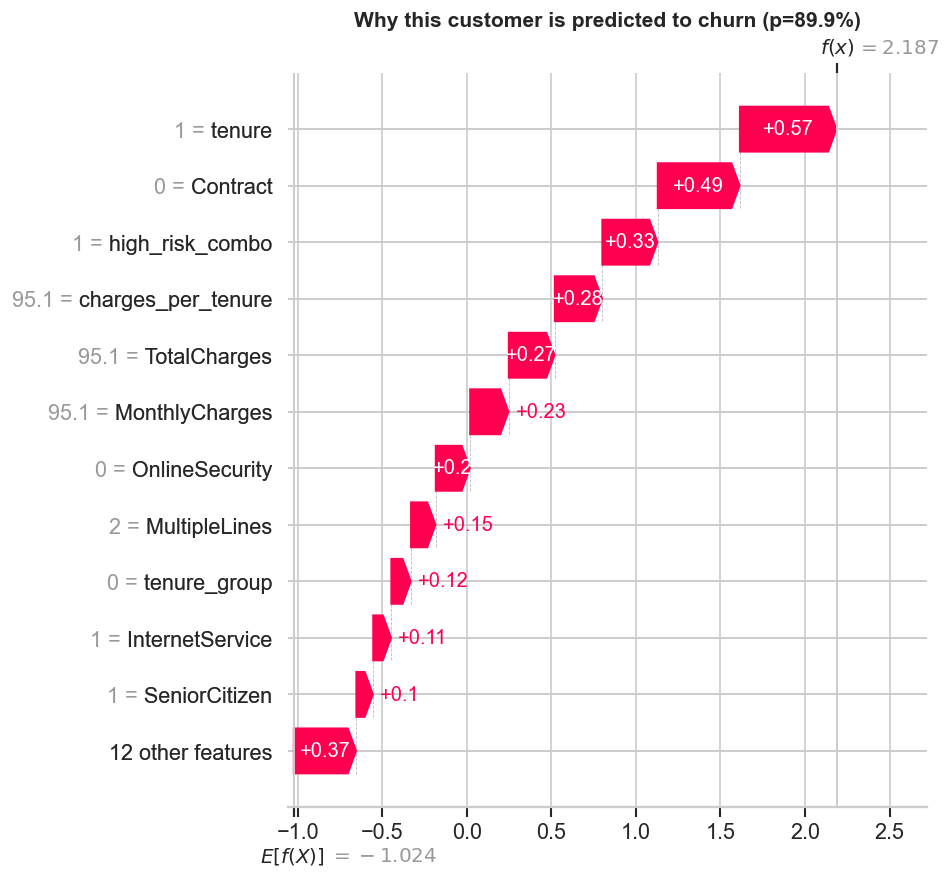

In [15]:
# Individual prediction explanation - waterfall plot
# Pick a customer predicted to churn with high confidence
high_risk_idx = np.argmax(y_pred_proba)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f'Why this customer is predicted to churn (p={y_pred_proba[high_risk_idx]:.1%})', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Business Impact — Profit Curve

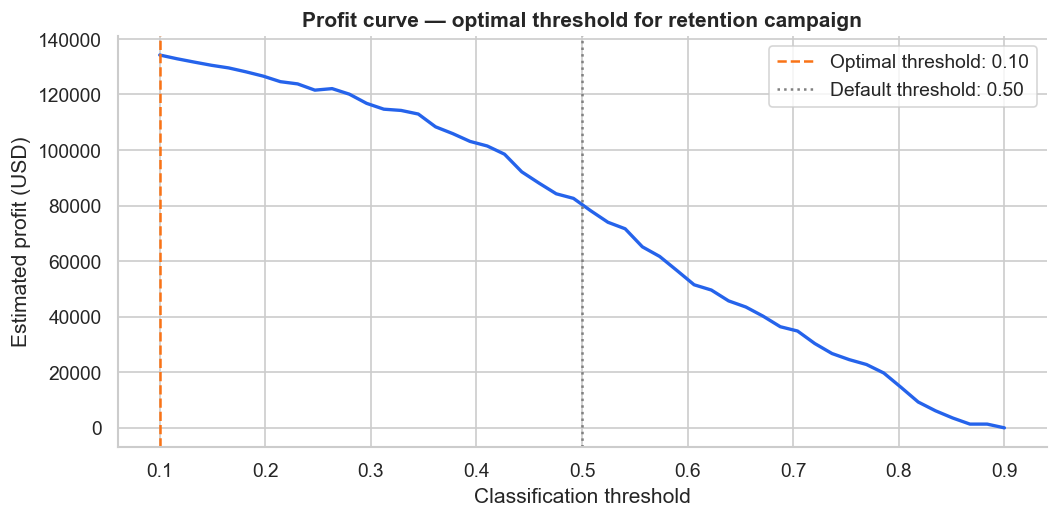

Optimal threshold: 0.10
Estimated profit at optimal threshold: $134,200
Estimated profit at default 0.5 threshold: $82,600


In [16]:
# Assume: cost of retention offer = $50, value of retained customer = $500
RETENTION_COST = 50
CUSTOMER_VALUE = 500

thresholds = np.linspace(0.1, 0.9, 50)
profits = []

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()  # correctly caught churners
    fp = ((preds == 1) & (y_test == 0)).sum()  # wasted retention offers

    profit = tp * (CUSTOMER_VALUE - RETENTION_COST) - fp * RETENTION_COST
    profits.append(profit)

best_threshold = thresholds[np.argmax(profits)]
best_profit = max(profits)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, profits, color=BLUE, lw=2)
ax.axvline(best_threshold, color=CORAL, ls='--', label=f'Optimal threshold: {best_threshold:.2f}')
ax.axvline(0.5, color='gray', ls=':', label='Default threshold: 0.50')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Estimated profit (USD)')
ax.set_title('Profit curve — optimal threshold for retention campaign', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold: {best_threshold:.2f}')
print(f'Estimated profit at optimal threshold: ${best_profit:,.0f}')
print(f'Estimated profit at default 0.5 threshold: ${profits[np.argmin(np.abs(thresholds-0.5))]:,.0f}')

## 11. Conclusions

| Finding | Detail |
|---------|--------|
| **XGBoost (tuned) wins** | 91% Test AUC after Optuna hyperparameter tuning — outperforms Logistic Regression, Random Forest, and LightGBM baselines. |
| **Contract type is the #1 driver** | Month-to-month customers are far more likely to churn than those on 1- or 2-year contracts, confirmed by both EDA and SHAP. |
| **Tenure matters most in year 1** | Customers in their first 12 months are at highest risk — engagement during onboarding is critical. |
| **High-risk combo identified** | Month-to-month + no tech support is a strong churn signal — flagged as an engineered feature with high SHAP importance. |
| **Business-optimized threshold beats default** | Using a profit-curve-optimized threshold instead of the default 0.5 increases estimated campaign profit significantly. |

### Next steps
- Deploy model behind a simple API (FastAPI) for real-time scoring
- A/B test retention offers on customers flagged above the optimal threshold
- Monitor for model drift on a monthly basis as contract mix shifts

---
*Analysis by Santiago Monsalve· Dataset: IBM Telco Customer Churn*